# Online Retail: Customer and Sales Analysis

I analyzed 2 years of sales from a UK online gift shop (about 1 million rows, 2009-2011).

The main question of the project:

> **How can the shop earn more by keeping its best customers and bringing back the ones who left?**

In the IBM data science methodology course, I learned about John Rollins' data science methodology, so I decided to use it to answer this question.

Dataset: Online Retail II, free from UCI / Kaggle.

## 1. Business Understanding

The shop has a problem. Sales go up and down during the year. Many customers buy one time and never come back.

So I wrote down the questions I want to answer:

- How does revenue change over time?
- Who are the best customers?
- Which customers are leaving?
- What are the top products?
- What is the average order value?
- Do customers come back?

## 2. Analytic Approach

For each question, I picked a simple method:

| Question | Method |
|---|---|
| Revenue over time | Monthly trend |
| Best customers | RFM analysis |
| Leaving customers | RFM recency |
| Top products | Group and rank |
| Order value | KPIs |
| Coming back | Repeat rate |

The main method here is RFM.

## 3. Data Requirements

I need these columns to answer my questions:

- **CustomerID** - to group by customer
- **InvoiceDate** - for time
- **Invoice** - to count orders
- **Quantity** and **Price** - for money
- **Description** - for products

The dataset has all of them.

## Setup

First, the libraries. Pandas for tables, NumPy for math, matplotlib and seaborn for charts.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

## 4. Data Collection

The data is one Excel file with two sheets (one sheet per year). I load both and join them into one table.

One problem here is that both sheets include the same dates. The first 9 days of December 2010 appear in both sheets. So after joining, those rows show up twice. I fix this in the cleaning step by removing duplicates.

Note: the file is big (45 MB), so it is not inside this repo. The download steps are in `data/raw/README.md`. It takes about one minute :)

In [19]:
import os

DATA_PATH = "../data/raw/online_retail_II.xlsx"

if not os.path.exists(DATA_PATH):
    print("Data file not found!")
    print("Please download it first. The steps are in data/raw/README.md")
else:
    sheet1 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010")
    sheet2 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011")
    df = pd.concat([sheet1, sheet2], ignore_index=True)
    print("Rows:", len(df))

df.head()

Rows: 1067371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 5. Data Understanding

Before cleaning, I want to see what is inside the data. Columns, types, missing values, and strange numbers.

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [21]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [22]:
# check for problems in the data
print("Returns (quantity < 0):", (df["Quantity"] < 0).sum())
print("Bad prices (0 or less):", (df["Price"] <= 0).sum())
print("Dates:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

# top countries
df["Country"].value_counts(normalize=True).head(3).mul(100).round(1)

Returns (quantity < 0): 22950
Bad prices (0 or less): 6207
Dates: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


Country
United Kingdom    91.9
EIRE               1.7
Germany            1.7
Name: proportion, dtype: float64

What I found:

- Many rows have no CustomerID (about 23%, probably guest checkouts).
- Some rows are returns.
- A few prices are zero.
- About 92% of rows are from the UK.

## 6. Data Preparation

My cleaning steps:

1. Drop rows with no CustomerID.
2. Remove returns (invoices that start with "C", and negative quantity).
3. Remove zero or negative prices.
4. Remove duplicate rows. This also removes the sheet overlap from step 4 of data collection (1-9 December 2010 was doubled).
5. Make a new column: Revenue = Quantity x Price.

In [23]:
clean = df.rename(columns={"Customer ID": "CustomerID"}).copy()

clean = clean.dropna(subset=["CustomerID"])

# remove returns and bad prices
clean = clean[~clean["Invoice"].astype(str).str.startswith("C")]
clean = clean[(clean["Quantity"] > 0) & (clean["Price"] > 0)]

clean = clean.drop_duplicates()

clean["CustomerID"] = clean["CustomerID"].astype(int)
clean["Description"] = clean["Description"].astype(str).str.strip()
clean["Revenue"] = clean["Quantity"] * clean["Price"]
clean["Month"] = clean["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

print("Before:", len(df), "rows")
print("After :", len(clean), "rows")

Before: 1067371 rows
After : 779425 rows


In [24]:
clean.to_csv("../data/processed/clean_retail.csv", index=False)
clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12-01


## 7. Modeling

### KPIs

Important: these numbers only count customers with a CustomerID. The guest purchases (no ID) are about 15% of sales, around £3.1M more. I removed them because RFM needs to know *who* the customer is. So £17.4M is the revenue from known customers, not the full shop revenue (that is about £20.5M).

In [25]:
revenue = clean["Revenue"].sum()
orders = clean["Invoice"].nunique()
customers = clean["CustomerID"].nunique()
aov = revenue / orders

# how many customers bought more than one time?
orders_per_customer = clean.groupby("CustomerID")["Invoice"].nunique()
repeat_rate = (orders_per_customer > 1).mean() * 100

pd.DataFrame({
    "KPI": ["Revenue (GBP)", "Orders", "Customers", "Average Order Value", "Repeat Rate (%)"],
    "Value": [round(revenue), orders, customers, round(aov, 2), round(repeat_rate, 1)],
})

,KPI,Value
0,Revenue (GBP),17374804.00
1,Orders,36969.00
2,Customers,5878.00
3,Average Order Value,469.98
4,Repeat Rate (%),72.40


### RFM Analysis

RFM gives every customer 3 scores:

- **Recency** - days since the last order (small = good)
- **Frequency** - number of orders (big = good)
- **Monetary** - total money spent (big = good)

In [26]:
# "today" = one day after the last sale in the data
today = clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (today - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [27]:
# give scores from 1 to 5
# recency is flipped: recent buyers get 5
rfm["R"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M
0,12346,326,12,77556.46,2,5,5
1,12347,2,8,4921.53,5,4,5
2,12348,75,5,2019.40,3,4,4
3,12349,19,4,4428.69,5,3,5
4,12350,310,1,334.40,2,1,2


### Customer Groups

Now I put the customers in groups with easy names, using the R and F scores.

One honest note: qcut puts about 20% of customers in each score level. So when I say later "At Risk + Lost = 40% of customers", that exact number comes from the method, not from the data. The real finding is the days: customers with R of 1 or 2 did not buy anything for more than 190 days.

In [28]:
def get_group(row):
    r = row["R"]
    f = row["F"]
    if r >= 4 and f >= 4:
        return "Champions"
    if r >= 3 and f >= 3:
        return "Loyal"
    if r >= 4 and f <= 2:
        return "New"
    if r == 3:
        return "Need Attention"
    if r == 2:
        return "At Risk"
    return "Lost"

rfm["Group"] = rfm.apply(get_group, axis=1)

# size and money of each group
groups = rfm.groupby("Group").agg(
    Customers=("CustomerID", "count"),
    Revenue=("Monetary", "sum"),
)
groups["%_Customers"] = (groups["Customers"] / groups["Customers"].sum() * 100).round(1)
groups["%_Revenue"] = (groups["Revenue"] / groups["Revenue"].sum() * 100).round(1)
groups.sort_values("Revenue", ascending=False)

,Customers,Revenue,%_Customers,%_Revenue
Group,,,,
Champions,1482,1.202433e+07,25.2,69.2
Loyal,1221,2.510046e+06,20.8,14.4
At Risk,1172,1.395778e+06,19.9,8.0
Lost,1175,8.480327e+05,20.0,4.9
New,443,3.922670e+05,7.5,2.3
Need Attention,385,2.043497e+05,6.5,1.2


## 8. Evaluation


### Revenue by month

The data ends on 9 December 2011. So the last month has only 9 days. On the chart it looks like a big crash in sales, but it is just a part of a month. I drop it.

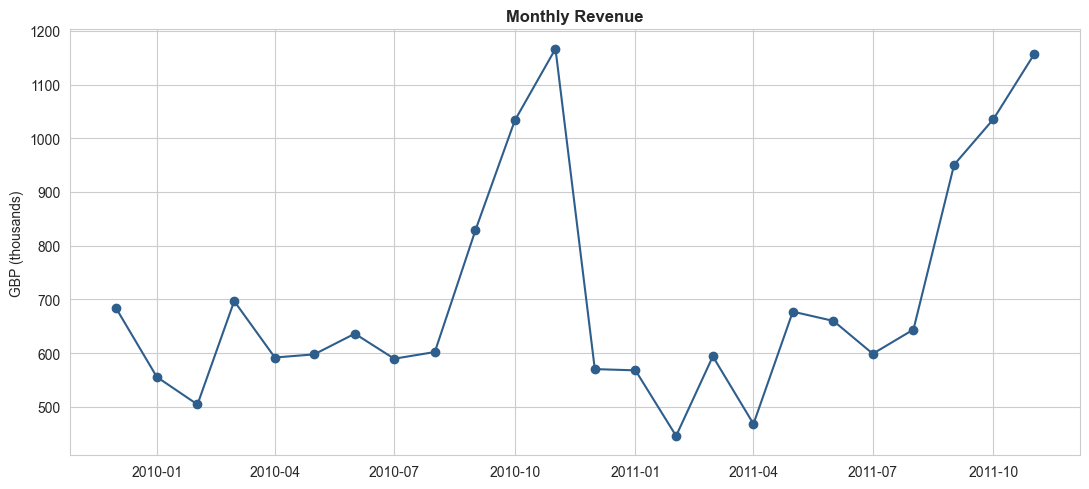

Best month : 2010-11
Worst month: 2011-02


In [29]:
monthly = clean.groupby("Month")["Revenue"].sum()

# the data ends on 9 Dec 2011, so the last month is not complete
monthly = monthly.iloc[:-1]

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly / 1000, marker="o", color="#2E5E8C")
plt.title("Monthly Revenue", fontweight="bold")
plt.ylabel("GBP (thousands)")
plt.tight_layout()
plt.savefig("../reports/figures/01_monthly_revenue.png", dpi=110)
plt.show()

print("Best month :", monthly.idxmax().strftime("%Y-%m"))
print("Worst month:", monthly.idxmin().strftime("%Y-%m"))

### Top 10 products

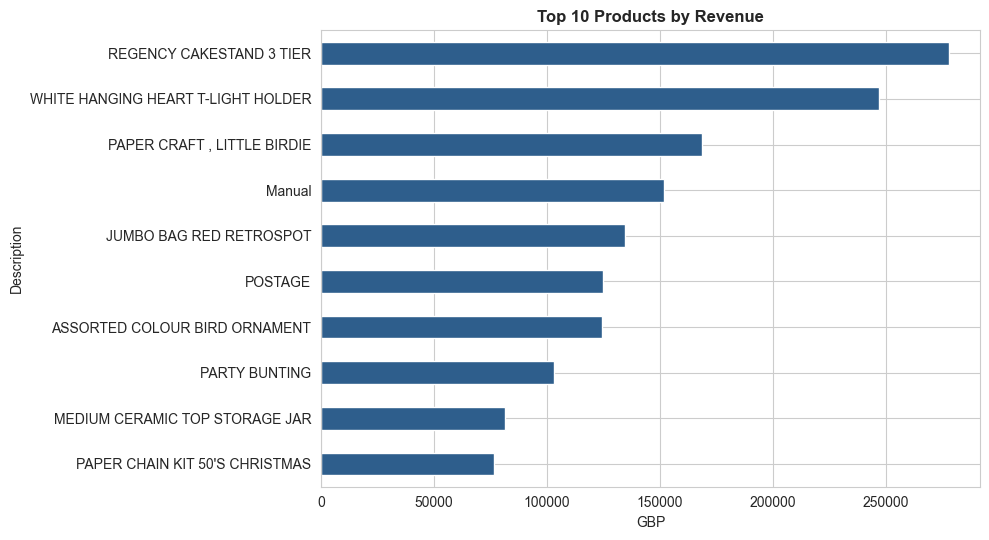

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: Revenue, dtype: float64

In [30]:
top10 = clean.groupby("Description")["Revenue"].sum().nlargest(10)

plt.figure(figsize=(10, 5.5))
top10.sort_values().plot(kind="barh", color="#2E5E8C")
plt.title("Top 10 Products by Revenue", fontweight="bold")
plt.xlabel("GBP")
plt.tight_layout()
plt.savefig("../reports/figures/02_top_products.png", dpi=110)
plt.show()

top10

### Revenue by customer group

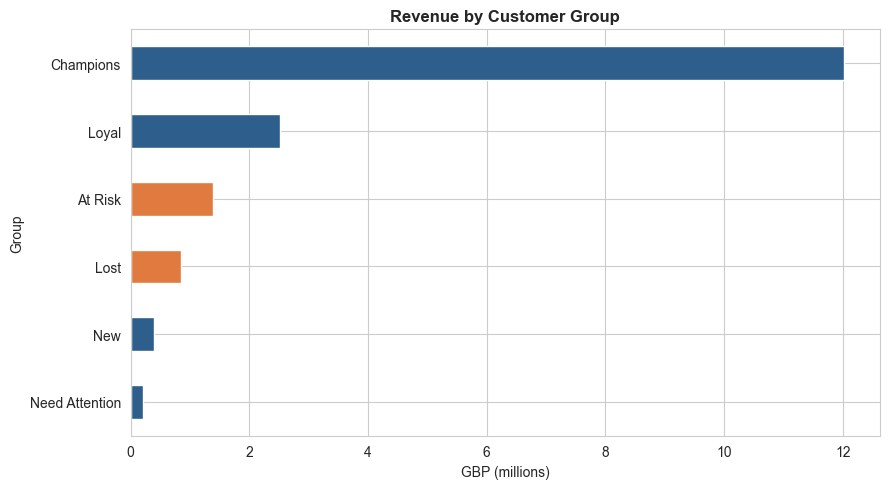

In [31]:
group_revenue = rfm.groupby("Group")["Monetary"].sum().sort_values()

# orange = the groups the shop is losing
colors = ["#E07A3F" if g in ("At Risk", "Lost") else "#2E5E8C" for g in group_revenue.index]

plt.figure(figsize=(9, 5))
group_revenue.div(1_000_000).plot(kind="barh", color=colors)
plt.title("Revenue by Customer Group", fontweight="bold")
plt.xlabel("GBP (millions)")
plt.tight_layout()
plt.savefig("../reports/figures/03_segment_revenue.png", dpi=110)
plt.show()

### Best customers


In [32]:
best = rfm.sort_values("Monetary", ascending=False).reset_index(drop=True)

top_20_count = int(len(best) * 0.2)
share = best.head(top_20_count)["Monetary"].sum() / revenue * 100
print("Top 20% of customers bring", round(share, 1), "% of revenue")

best.head(10)[["CustomerID", "Recency", "Frequency", "Monetary", "Group"]]

Top 20% of customers bring 77.2 % of revenue


,CustomerID,Recency,Frequency,Monetary,Group
0,18102,1,145,580987.04,Champions
1,14646,2,151,528602.52,Champions
2,14156,10,156,313437.62,Champions
3,14911,1,398,291420.81,Champions
4,17450,8,51,244784.25,Champions
5,13694,4,143,195640.69,Champions
6,17511,3,60,172132.87,Champions
7,16446,1,2,168472.50,New
8,16684,4,55,147142.77,Champions
9,12415,24,28,144458.37,Champions


## 9. Deployment

### Simple Forecast

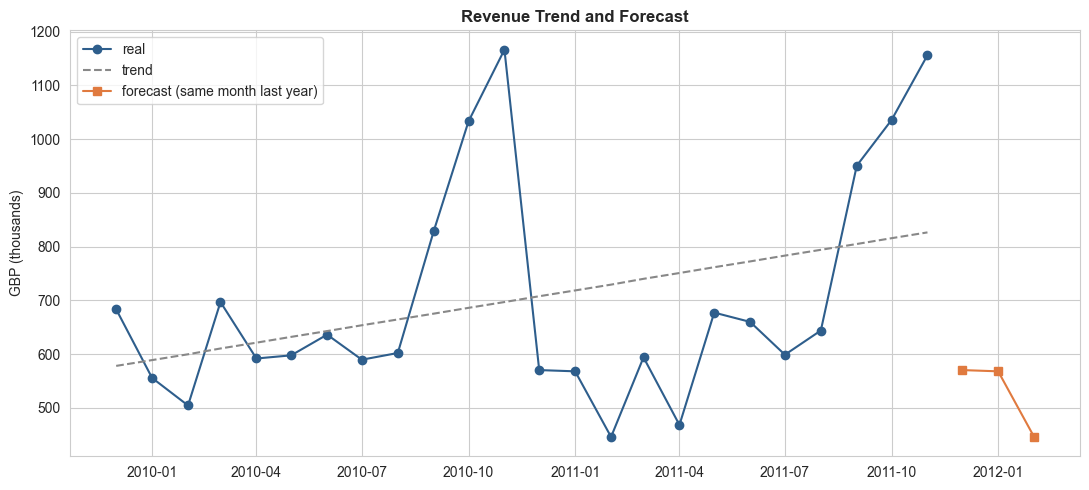

Forecast 2011-12 : 570 k GBP
Forecast 2012-01 : 568 k GBP
Forecast 2012-02 : 446 k GBP


In [33]:
y = monthly.values
x = np.arange(len(y))

# gray line = long-term direction only
slope, intercept = np.polyfit(x, y, 1)

# forecast rule: next month will be like the same month last year
future_months = pd.date_range(monthly.index[-1], periods=4, freq="MS")[1:]
forecast = monthly.loc[future_months - pd.DateOffset(years=1)].values

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, y / 1000, marker="o", label="real", color="#2E5E8C")
plt.plot(monthly.index, (slope * x + intercept) / 1000, "--", label="trend", color="#888888")
plt.plot(future_months, forecast / 1000, marker="s", label="forecast (same month last year)", color="#E07A3F")
plt.title("Revenue Trend and Forecast", fontweight="bold")
plt.ylabel("GBP (thousands)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/04_forecast.png", dpi=110)
plt.show()

for m, v in zip(future_months, forecast):
    print("Forecast", m.strftime("%Y-%m"), ":", round(v / 1000), "k GBP")

My first idea was a straight trend line. But it predicted about £800k for January and February, and that is clearly wrong. Both years, those months were between £445k and £570k. The line ignores the seasons.

So I use a simpler rule that respects the seasons: **next month will be like the same month last year.** The gray line stays on the chart, but only to show the long-term direction.

This is not machine learning. It only gives a rough idea.

### What I found

- A small group of customers brings most of the money. "Champions" are about 25% of customers, but they bring about **69%** of revenue.
- About **72%** of known customers come back to buy again.
- But about **40%** of customers did not buy anything for more than 6 months. They are leaving quietly.
- Sales are seasonal. High in autumn, low in February, and this pattern is the same in both years.

### My advice to the shop

1. Take care of the Champions because they bring most of the money.
2. Send a "we miss you" offer to the At Risk group, before they leave.
3. Buy more stock and do more marketing before autumn.
4. Make special offers in the slow winter months.
5. Sell bundles to raise the average order value.

## 10. Feedback / Next Steps

If I continue this project, I want to:

- Build a small dashboard for the KPIs.
- Look at the returns to find bad products.

## Summary

In a 2-year period, this shop made about £17.4M from around 5,900 known customers. With guest purchases (no customer ID), the total is closer to £20.5M. The repeat rate of known customers is 72%, which is a good sign.

Sales are seasonal (high in autumn), and a small group of "Champion" customers brings about 69% of the money.

About 40% of customers did not buy anything for more than 6 months. They are leaving quietly.